In [ ]:
!pip install xgboost lightgbm optuna shap holidays -q

import pandas as pd
import numpy as np
import os
import math
import warnings
import holidays
import xgboost as xgb
import lightgbm as lgb
import optuna
import shap
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Tạo thư mục nếu chưa có
data_path = '.' # Changed from 'data' to '.'
os.makedirs('data', exist_ok=True)
os.makedirs('datathon-2026-round-1', exist_ok=True)

print("Đã cài đặt xong thư viện và tạo thư mục. Hãy đảm bảo bạn đã upload dữ liệu.")

Đã cài đặt xong thư viện và tạo thư mục. Hãy đảm bảo bạn đã upload dữ liệu.


In [ ]:
print("1. Reading sales data...")
sales_df = pd.read_csv(os.path.join(data_path, 'daily_sales_data_final.csv'))
sales_df['date'] = pd.to_datetime(sales_df['date'])
sales_df = sales_df.sort_values('date').reset_index(drop=True)

print("2. Tinh chỉnh Lịch & Ngày Lễ (Holidays)...")
sales_df['year'] = sales_df['date'].dt.year
sales_df['month'] = sales_df['date'].dt.month
sales_df['day'] = sales_df['date'].dt.day
sales_df['dayofweek'] = sales_df['date'].dt.dayofweek
sales_df['is_weekend'] = sales_df['dayofweek'].isin([5, 6]).astype(int)
sales_df['quarter'] = sales_df['date'].dt.quarter
sales_df['dayofyear'] = sales_df['date'].dt.dayofyear
sales_df['week'] = sales_df['date'].dt.isocalendar().week.astype(int)

K = 2
for k in range(1, K + 1):
    sales_df[f'sin_year_{k}'] = np.sin(2 * math.pi * k * sales_df['dayofyear'] / 365.25)
    sales_df[f'cos_year_{k}'] = np.cos(2 * math.pi * k * sales_df['dayofyear'] / 365.25)

vn_holidays = holidays.VN()
sales_df['is_holiday'] = sales_df['date'].apply(lambda x: 1 if x in vn_holidays else 0)

print("3. Khởi tạo Khuyến mãi...")
try:
    promo_path = os.path.join('datathon-2026-round-1', 'promotions.csv')
    promo_df = pd.read_csv(promo_path)
    promo_df['start_date'] = pd.to_datetime(promo_df['start_date'])
    promo_df['end_date'] = pd.to_datetime(promo_df['end_date'])
    def check_promo(date):
        active = promo_df[(promo_df['start_date'] <= date) & (promo_df['end_date'] >= date)]
        return 1 if len(active) > 0 else 0
    sales_df['is_promo_active'] = sales_df['date'].apply(check_promo)
except Exception as e:
    print("Warning: Could not process promotions:", e)
    sales_df['is_promo_active'] = 0

print("3.5 Áp dụng chuẩn hóa lạm phát (Inflation Normalization) bằng CPI...")
try:
    cpi_df = pd.read_csv('cpi.csv')
    cpi_df['Thời Gian'] = pd.to_datetime(cpi_df['Thời Gian'])
    cpi_df['year'] = cpi_df['Thời Gian'].dt.year
    cpi_df['month'] = cpi_df['Thời Gian'].dt.month

    sales_df = sales_df.merge(cpi_df[['year', 'month', 'CPI']], on=['year', 'month'], how='left')
    sales_df['CPI'] = sales_df['CPI'].ffill().bfill()
    sales_df['inflation_factor'] = sales_df['CPI'] / 100.0
    sales_df['actual_revenue'] = sales_df['actual_revenue'] / sales_df['inflation_factor']
except Exception as e:
    print("Warning: Could not process CPI data:", e)
    # If CPI data is not available, assume no inflation adjustment or handle as appropriate
    sales_df['inflation_factor'] = 1.0 # Or some default
    sales_df['CPI'] = 100.0 # Or some default

print("4. Sinh Features Lags dài hạn VÀ Bỏ các Lags gây đứt gãy tương lai...")
lag_features = ['actual_revenue']
for col in lag_features:
    sales_df[f'{col}_lag1'] = sales_df[col].shift(1)
    sales_df[f'{col}_lag7'] = sales_df[col].shift(7)
    sales_df[f'{col}_lag14'] = sales_df[col].shift(14)
    sales_df[f'{col}_lag30'] = sales_df[col].shift(30)

print("5. Sinh Gia tốc (Differential Features)...")
sales_df['revenue_diff_lag1_lag7'] = sales_df['actual_revenue_lag1'] - sales_df['actual_revenue_lag7']

print("6. Tái thiết lập Big Rolling & EWMA...")
sales_df['revenue_roll_mean_7_lag1'] = sales_df['actual_revenue'].shift(1).rolling(window=7).mean()
sales_df['revenue_roll_std_7_lag1']  = sales_df['actual_revenue'].shift(1).rolling(window=7).std()
sales_df['revenue_roll_mean_14_lag1'] = sales_df['actual_revenue'].shift(1).rolling(window=14).mean()
sales_df['revenue_roll_mean_30_lag1'] = sales_df['actual_revenue'].shift(1).rolling(window=30).mean()
sales_df['revenue_ewma_7_lag1'] = sales_df['actual_revenue'].shift(1).ewm(span=7).mean()
sales_df['revenue_ewma_30_lag1'] = sales_df['actual_revenue'].shift(1).ewm(span=30).mean()

leakage_cols = [c for c in sales_df.columns if 'revenue_category_' in c or 'revenue_segment' in c or 'revenue_color_' in c]
leakage_cols += ['gross_profit', 'order_id', 'quantity', 'customer_id', 'is_returned']

print("7. Trích chọn lại WebTraffic Rolling thay vì lag1...")
try:
    traffic_df = pd.read_csv(os.path.join(data_path, 'Fact_WebTraffic.csv'))
    date_col = next((c for c in traffic_df.columns if c.lower() == 'date'), None)
    if date_col:
        traffic_df['date'] = pd.to_datetime(traffic_df[date_col])
        if 'sessions' in traffic_df.columns:
            traffic_df['sessions_roll_30_lag1'] = traffic_df['sessions'].shift(1).rolling(30).mean()
            sales_df = sales_df.merge(traffic_df[['date', 'sessions_roll_30_lag1']], on='date', how='left')
except Exception as e:
    print("Warning: Could not process web traffic data:", e)

final_df = sales_df.dropna()
final_train_cols = [c for c in final_df.columns if c not in leakage_cols]
train_ready_df = final_df[final_train_cols]

train_ready_df.to_csv(os.path.join(data_path, 'train_ready_dataset.csv'), index=False)
print("Shape Final Data:", train_ready_df.shape)

1. Reading sales data...
2. Tinh chỉnh Lịch & Ngày Lễ (Holidays)...
3. Khởi tạo Khuyến mãi...
3.5 Áp dụng chuẩn hóa lạm phát (Inflation Normalization) bằng CPI...
4. Sinh Features Lags dài hạn VÀ Bỏ các Lags gây đứt gãy tương lai...
5. Sinh Gia tốc (Differential Features)...
6. Tái thiết lập Big Rolling & EWMA...
7. Trích chọn lại WebTraffic Rolling thay vì lag1...
Shape Final Data: (3803, 29)


In [ ]:
print("Chuẩn bị dữ liệu huấn luyện...")
train_df = pd.read_csv(os.path.join(data_path, 'train_ready_dataset.csv'))
train_df['date'] = pd.to_datetime(train_df['date'])
train_df = train_df.sort_values('date').reset_index(drop=True)

def get_inflation_factor(date):
    match = cpi_df[(cpi_df['year'] == date.year) & (cpi_df['month'] == date.month)]
    if len(match) > 0:
        return match.iloc[0]['CPI'] / 100.0
    return cpi_df.iloc[-1]['CPI'] / 100.0

target_col = 'actual_revenue'
ignore_cols = ['date', target_col, 'inflation_factor', 'CPI']
features = [c for c in train_df.columns if c not in ignore_cols]

n_samples = len(train_df)
c2 = int(0.8 * n_samples)

X_train_val = train_df.iloc[:c2][features]
y_train_val = train_df.iloc[:c2][target_col]
y_train_val_log = np.log1p(y_train_val)

X_test = train_df.iloc[c2:][features]
y_test = train_df.iloc[c2:][target_col]
y_test_log = np.log1p(y_test)

def eval_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

print("[OPTUNA] Tối ưu hóa mô hình với TSCV & Early Stopping...")
def objective(trial):
    param_xgb = {
        'n_estimators': trial.suggest_int('xgb_n_estimators', 100, 400),
        'learning_rate': trial.suggest_float('xgb_lr', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('xgb_max_depth', 3, 6),
        'objective': 'reg:squarederror',
        'n_jobs': -1,
        'random_state': 42
    }
    param_lgb = {
        'n_estimators': trial.suggest_int('lgb_n_estimators', 100, 400),
        'learning_rate': trial.suggest_float('lgb_lr', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('lgb_max_depth', 3, 6),
        'num_leaves': trial.suggest_int('lgb_leaves', 20, 60),
        'n_jobs': -1,
        'random_state': 42,
        'verbose': -1
    }
    tscv = TimeSeriesSplit(n_splits=3)
    cv_scores = []
    for train_index, val_index in tscv.split(X_train_val):
        X_tr, X_va = X_train_val.iloc[train_index], X_train_val.iloc[val_index]
        y_tr, y_va = y_train_val_log.iloc[train_index], y_train_val_log.iloc[val_index]

        m_xgb = xgb.XGBRegressor(**param_xgb, early_stopping_rounds=30)
        m_xgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)

        m_lgb = lgb.LGBMRegressor(**param_lgb)
        try:
            m_lgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], callbacks=[lgb.early_stopping(30, verbose=False)])
        except:
            m_lgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], early_stopping_rounds=30, verbose=False)

        pred_xgb_log = m_xgb.predict(X_va)
        pred_lgb_log = m_lgb.predict(X_va)
        pred_ens = np.expm1((pred_xgb_log + pred_lgb_log) / 2)

        val_inflation = train_df.iloc[:c2]['inflation_factor'].iloc[val_index].values
        mae, rmse, r2 = eval_metrics(np.expm1(y_va) * val_inflation, pred_ens * val_inflation)
        cv_scores.append(rmse)
    return np.mean(cv_scores)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=5)
print("Best Params:", study.best_params)

best = study.best_params
final_xgb = xgb.XGBRegressor(
    n_estimators=best['xgb_n_estimators'], learning_rate=best['xgb_lr'],
    max_depth=best['xgb_max_depth'], objective='reg:squarederror', n_jobs=-1, random_state=42)
final_lgb = lgb.LGBMRegressor(
    n_estimators=best['lgb_n_estimators'], learning_rate=best['lgb_lr'],
    max_depth=best['lgb_max_depth'], num_leaves=best['lgb_leaves'], n_jobs=-1, random_state=42, verbose=-1)

final_xgb.fit(X_train_val, y_train_val_log)
final_lgb.fit(X_train_val, y_train_val_log)

pred_xgb_test_log = final_xgb.predict(X_test)
pred_lgb_test_log = final_lgb.predict(X_test)
pred_ens_test = np.expm1((pred_xgb_test_log + pred_lgb_test_log) / 2)

test_inflation = train_df.iloc[c2:]['inflation_factor'].values
mae_test, rmse_test, r2_test = eval_metrics(y_test * test_inflation, pred_ens_test * test_inflation)
print(f"TEST MAE:  {mae_test:.4f}\nTEST RMSE: {rmse_test:.4f}\nTEST R²:   {r2_test:.4f}")

Chuẩn bị dữ liệu huấn luyện...
[OPTUNA] Tối ưu hóa mô hình với TSCV & Early Stopping...
Best Params: {'xgb_n_estimators': 331, 'xgb_lr': 0.03978941482456713, 'xgb_max_depth': 6, 'lgb_n_estimators': 351, 'lgb_lr': 0.028218528121837443, 'lgb_max_depth': 3, 'lgb_leaves': 29}
TEST MAE:  497487.8230
TEST RMSE: 701590.3712
TEST R²:   0.8132


1. Feature Importance (Top 10 - XGBoost):
actual_revenue_lag1          0.671646
day                          0.041645
actual_revenue_lag7          0.029718
revenue_roll_mean_30_lag1    0.027889
revenue_roll_mean_7_lag1     0.027131
dayofyear                    0.023834
cos_year_1                   0.018304
sin_year_1                   0.015734
revenue_ewma_7_lag1          0.014226
actual_revenue_lag14         0.014213
dtype: float32

2. Tính toán SHAP values...


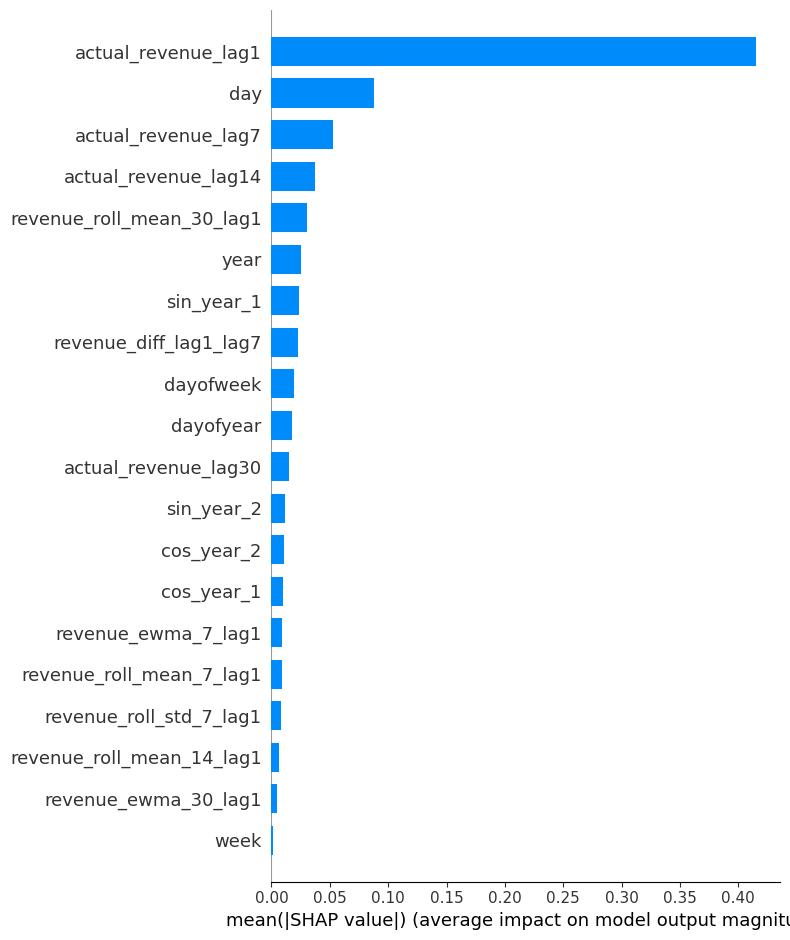


3. Tích hợp scikit-learn Pipeline...
Pipeline LGB Test R² (Log scale): 0.7911

4. Error Analysis (Top sai số lớn nhất):
      date      actual         pred    abs_error
2022-08-28 7051722.270 3.299468e+06 3.752255e+06
2021-05-30 8887935.600 5.527915e+06 3.360021e+06
2022-03-02 5221766.090 1.997548e+06 3.224218e+06
2022-02-26 6304749.980 3.122711e+06 3.182039e+06
2021-02-25 5586530.712 2.454791e+06 3.131739e+06


In [ ]:
print("1. Feature Importance (Top 10 - XGBoost):")
feature_importances = pd.Series(final_xgb.feature_importances_, index=features).sort_values(ascending=False)
print(feature_importances.head(10))

print("\n2. Tính toán SHAP values...")
explainer = shap.TreeExplainer(final_xgb)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, plot_type="bar")

print("\n3. Tích hợp scikit-learn Pipeline...")
pipeline_lgb = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('lgb', lgb.LGBMRegressor(
        n_estimators=best['lgb_n_estimators'],
        learning_rate=best['lgb_lr'],
        max_depth=best['lgb_max_depth'],
        num_leaves=best['lgb_leaves'],
        n_jobs=-1, random_state=42, verbose=-1))
])
pipeline_lgb.fit(X_train_val, y_train_val_log)
print(f"Pipeline LGB Test R² (Log scale): {pipeline_lgb.score(X_test, y_test_log):.4f}")

print("\n4. Error Analysis (Top sai số lớn nhất):")
error_df = pd.DataFrame({
    'date': train_df.iloc[c2:]['date'],
    'actual': y_test * test_inflation,
    'pred': pred_ens_test * test_inflation,
    'abs_error': np.abs((y_test * test_inflation) - (pred_ens_test * test_inflation))
})
print(error_df.sort_values('abs_error', ascending=False).head(5).to_string(index=False))

In [ ]:
print("Retrain Ensemble model trên toàn bộ dữ liệu...")
X_all = train_df[features]
y_all_log = np.log1p(train_df[target_col])
final_xgb.fit(X_all, y_all_log)
final_lgb.fit(X_all, y_all_log)

print("Đọc dữ liệu lạm phát từ cpi.csv cho dự báo tương lai...")
# Đọc trực tiếp cpi.csv tại đây để chống lỗi mất biến (undefined variable)
cpi_df = pd.read_csv('cpi.csv')
cpi_df['Thời Gian'] = pd.to_datetime(cpi_df['Thời Gian'])
cpi_df['year'] = cpi_df['Thời Gian'].dt.year
cpi_df['month'] = cpi_df['Thời Gian'].dt.month

def get_inflation_factor_inference(date):
    match = cpi_df[(cpi_df['year'] == date.year) & (cpi_df['month'] == date.month)]
    if len(match) > 0:
        return match.iloc[0]['CPI'] / 100.0
    # Nếu ngày dự báo vượt quá dữ liệu CPI hiện có, lấy tháng gần nhất (forward fill)
    return cpi_df.iloc[-1]['CPI'] / 100.0

print("Bắt đầu nội suy tương lai (Inference) không đứt quãng...")
sub_file = os.path.join('datathon-2026-round-1', 'sample_submission.csv')
sample_sub = pd.read_csv(sub_file)
sample_sub['Date'] = pd.to_datetime(sample_sub['Date'])
future_dates = sample_sub.sort_values('Date')['Date'].tolist()

history_df = train_df.tail(60).copy()
predictions = []

for cur_date in future_dates:
    row_dict = {'date': cur_date}
    row_dict['year'] = cur_date.year
    row_dict['month'] = cur_date.month
    row_dict['day'] = cur_date.day
    row_dict['dayofweek'] = cur_date.dayofweek
    row_dict['is_weekend'] = int(cur_date.dayofweek in [5, 6])
    row_dict['quarter'] = (cur_date.month - 1) // 3 + 1

    dayofyear = cur_date.timetuple().tm_yday
    row_dict['dayofyear'] = dayofyear
    row_dict['week'] = int(cur_date.isocalendar()[1])

    for k in range(1, K + 1):
        row_dict[f'sin_year_{k}'] = np.sin(2 * math.pi * k * dayofyear / 365.25)
        row_dict[f'cos_year_{k}'] = np.cos(2 * math.pi * k * dayofyear / 365.25)

    row_dict['is_holiday'] = 1 if cur_date in vn_holidays else 0
    row_dict['is_promo_active'] = 0

    # Lấy CPI chuẩn từ hàm cục bộ vừa định nghĩa
    row_dict['CPI'] = get_inflation_factor_inference(cur_date) * 100.0

    for f in features:
        if f == target_col + '_lag1':
            row_dict[f] = history_df.iloc[-1][target_col]
        elif f == target_col + '_lag7':
            row_dict[f] = history_df.iloc[-7][target_col] if len(history_df)>=7 else history_df.iloc[-1][target_col]
        elif f == target_col + '_lag14':
            row_dict[f] = history_df.iloc[-14][target_col] if len(history_df)>=14 else history_df.iloc[-1][target_col]
        elif f == target_col + '_lag30':
            row_dict[f] = history_df.iloc[-30][target_col] if len(history_df)>=30 else history_df.iloc[-1][target_col]

    if 'revenue_diff_lag1_lag7' in features:
        row_dict['revenue_diff_lag1_lag7'] = row_dict.get(target_col + '_lag1', 0) - row_dict.get(target_col + '_lag7', 0)

    last_7_revs = history_df[target_col].tail(7)
    last_14_revs = history_df[target_col].tail(14)
    last_30_revs = history_df[target_col].tail(30)

    if 'revenue_roll_mean_7_lag1' in features: row_dict['revenue_roll_mean_7_lag1'] = last_7_revs.mean()
    if 'revenue_roll_std_7_lag1' in features: row_dict['revenue_roll_std_7_lag1'] = last_7_revs.std()
    if 'revenue_roll_mean_14_lag1' in features: row_dict['revenue_roll_mean_14_lag1'] = last_14_revs.mean()
    if 'revenue_roll_mean_30_lag1' in features: row_dict['revenue_roll_mean_30_lag1'] = last_30_revs.mean()

    if 'revenue_ewma_7_lag1' in features: row_dict['revenue_ewma_7_lag1'] = last_7_revs.ewm(span=7).mean().iloc[-1] if len(last_7_revs)>0 else 0
    if 'revenue_ewma_30_lag1' in features: row_dict['revenue_ewma_30_lag1'] = last_30_revs.ewm(span=30).mean().iloc[-1] if len(last_30_revs)>0 else 0

    for f in features:
        if f not in row_dict:
            row_dict[f] = history_df.iloc[-1][f]

    cur_X = pd.DataFrame([row_dict])[features]

    pred_xgb_log = final_xgb.predict(cur_X)[0]
    pred_lgb_log = final_lgb.predict(cur_X)[0]

    pred_revenue = np.expm1((pred_xgb_log + pred_lgb_log) / 2.0)
    if pred_revenue < 0: pred_revenue = 0

    cur_inf = row_dict['CPI'] / 100.0
    predictions.append(pred_revenue * cur_inf)

    row_dict[target_col] = pred_revenue
    history_df = pd.concat([history_df, pd.DataFrame([row_dict])], ignore_index=True)

print(f"Đã nội suy liên tiếp {len(predictions)} ngày (tương lai khép kín).")
sample_sub['Revenue'] = predictions
output_file = os.path.join('datathon-2026-round-1', 'submission.csv')
sample_sub.to_csv(output_file, index=False)
print(f"🎉 Ghi xong kết quả cuối cùng tại: {output_file}")

Retrain Ensemble model trên toàn bộ dữ liệu...
Đọc dữ liệu lạm phát từ cpi.csv cho dự báo tương lai...
Bắt đầu nội suy tương lai (Inference) không đứt quãng...
Đã nội suy liên tiếp 548 ngày (tương lai khép kín).
🎉 Ghi xong kết quả cuối cùng tại: datathon-2026-round-1/submission.csv
